# Lectura de paquetes y data

In [1]:
import warnings
import os
import time
import sys
import ast

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from statsmodels.tsa.seasonal import STL

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error, mean_squared_error

import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)  # Reduce verbosity de Optuna


# Agrega todo el directorio padre al path
sys.path.append(os.path.abspath(".."))
from src.utils_ml import ml_training_utils as ml_utils
from src.utils_ml import ml_feature_engineering as fe_utils
from src.utils_ml import ml_plotting as plot_utils

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
warnings.filterwarnings("ignore")

/opt/homebrew/Caskroom/miniconda/base/envs/maestria/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Utilizamos paths relativos para la lectura de la data

In [2]:
filename = "ml_pipeline_p_sku.ipynb"  # nombre del archivo actual
print(f"Current absolute path: {os.getcwd()}\n")

# Especificamos la ruta del directorio actual y los directorios de datos y salida
ACTUAL_DIR = os.path.dirname(os.path.abspath(filename))
BASE_DIR = os.path.dirname(ACTUAL_DIR)
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(DATA_DIR, "output")

print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

Current absolute path: /Users/jhonattan.reales/Documents/Personal_jhonattan/Icesi/Innova_tec1/innv_tec_1_icesi/notebooks

BASE_DIR: /Users/jhonattan.reales/Documents/Personal_jhonattan/Icesi/Innova_tec1/innv_tec_1_icesi
DATA_DIR: /Users/jhonattan.reales/Documents/Personal_jhonattan/Icesi/Innova_tec1/innv_tec_1_icesi/data
OUTPUT_DIR: /Users/jhonattan.reales/Documents/Personal_jhonattan/Icesi/Innova_tec1/innv_tec_1_icesi/data/output


In [3]:
# Cargar el archivo de Excel
file_path = os.path.join(DATA_DIR, "data_demanda.xlsx")
df_base = pd.read_excel(file_path, sheet_name="data")
df_base = df_base.drop("Cliente", axis=1)

df_base.shape

(6834, 11)

In [4]:
df_base.head(5)

,Fe.prefer.entrega,Day_of_the_Week,Pedidos,Sell_In,Sell_in_on_time,CEDIS,SKU,Mes_Año,Sell_in_rezago,porcentaje_on_time,Subcategoria
0,2024-07-05,Friday,16200,16200,16200,7,SKU7,72024,0,1.0,BEBIDAS DE YOGUR
1,2024-07-05,Friday,19800,19800,19800,6,SKU5,72024,0,1.0,BEBIDAS DE YOGUR
2,2024-07-05,Friday,4950,4950,4950,4,SKU6,72024,0,1.0,BEBIDAS DE YOGUR
3,2024-07-05,Friday,8100,8100,8100,6,SKU4,72024,0,1.0,BEBIDAS DE YOGUR
4,2024-07-05,Friday,18600,18600,18600,7,SKU3,72024,0,1.0,BEBIDAS DE YOGUR


In [53]:
df_base

,Fe.prefer.entrega,Day_of_the_Week,Pedidos,Sell_In,Sell_in_on_time,CEDIS,SKU,Mes_Año,Sell_in_rezago,porcentaje_on_time,Subcategoria
0,2024-07-05,Friday,16200,16200,16200,7,SKU7,72024,0,1.000000,BEBIDAS DE YOGUR
1,2024-07-05,Friday,19800,19800,19800,6,SKU5,72024,0,1.000000,BEBIDAS DE YOGUR
2,2024-07-05,Friday,4950,4950,4950,4,SKU6,72024,0,1.000000,BEBIDAS DE YOGUR
3,2024-07-05,Friday,8100,8100,8100,6,SKU4,72024,0,1.000000,BEBIDAS DE YOGUR
4,2024-07-05,Friday,18600,18600,18600,7,SKU3,72024,0,1.000000,BEBIDAS DE YOGUR
...,...,...,...,...,...,...,...,...,...,...,...
6829,2025-04-10,Thursday,1560,1560,1560,2,SKU14,42025,0,1.000000,FIOCOSSOS
6830,2025-04-10,Thursday,3900,3900,3900,2,SKU16,42025,0,1.000000,LECHE PASTEURIZADA
6831,2025-04-10,Thursday,4200,0,0,3,SKU8,42025,0,0.000000,YOGUR BOTELLA
6832,2025-04-10,Thursday,2160,1764,1764,3,SKU22,42025,0,0.816667,YOGUR VASOS


In [5]:
# Filtrar los datos relevantes para este analisis

df = (
    df_base[["Fe.prefer.entrega", "SKU", "Pedidos"]]
    .copy()
    .rename(
        columns={
            "Fe.prefer.entrega": "Fecha",
        }
    )
)
df["Pedidos"] = pd.to_numeric(df["Pedidos"], errors="coerce")

In [6]:
df

,Fecha,SKU,Pedidos
0,2024-07-05,SKU7,16200
1,2024-07-05,SKU5,19800
2,2024-07-05,SKU6,4950
3,2024-07-05,SKU4,8100
4,2024-07-05,SKU3,18600
...,...,...,...
6829,2025-04-10,SKU14,1560
6830,2025-04-10,SKU16,3900
6831,2025-04-10,SKU8,4200
6832,2025-04-10,SKU22,2160


# Preparación de la data

In [7]:
### Primero, nos aseguramos de que se cuente un dato por SKU por dia
# -------

# rango completo de fechas desde la más antigua hasta la más reciente
fecha_min = df["Fecha"].min()
fecha_max = df["Fecha"].max()
rango_fechas = pd.date_range(start=fecha_min, end=fecha_max, freq="D")

# Obtenemos todos los SKUs únicos
skus = df["SKU"].unique()

# DataFrame con todas las combinaciones de SKU y fecha
combinaciones_completas = pd.MultiIndex.from_product(
    [rango_fechas, skus], names=["Fecha", "SKU"]
).to_frame(index=False)

# Unir con el dataframe original para rellenar con ceros donde falten datos
df_completo = combinaciones_completas.merge(df, on=["Fecha", "SKU"], how="left")

# Rellenar valores faltantes de pedidos con 0
df_completo["Pedidos"] = df_completo["Pedidos"].fillna(0).astype(int)

# Ordenar por SKU y Fecha (opcional)
df_completo = df_completo.sort_values(["SKU", "Fecha"]).reset_index(drop=True)

df = df_completo.copy()

In [8]:
# Modificar nombre de columnas
df.columns = df.columns.str.replace(".", "_", regex=False).str.lower()

In [9]:
df.shape

(7280, 3)

# EDA

## general

In [10]:
df.isna().sum()

fecha      0
sku        0
pedidos    0
dtype: int64

In [11]:
# porcentaje de ceros por sku
porcentaje_ceros = (
    df.groupby("sku")["pedidos"]
    .apply(lambda x: (x == 0).mean() * 100)
    .reset_index(name="prct_ceros")
    .round(2)
)

# promedio, mediana y desviacion estandar por sku excluyendo ceros
df_temp = df[df["pedidos"] > 0].copy()
promedio = df_temp.groupby("sku")["pedidos"].mean().reset_index(name="Promedio").round()
mediana = df_temp.groupby("sku")["pedidos"].median().reset_index(name="Mediana").round()
desviacion = (
    df_temp.groupby("sku")["pedidos"].std().reset_index(name="Desviacion").round()
)
maximo = df_temp.groupby("sku")["pedidos"].max().reset_index(name="Maximo").round()

# Porcentaje de valores outliers por SKU excluyendo ceros
porcentaje_outliers = (
    df_temp.groupby("sku")["pedidos"]
    .apply(fe_utils.calcular_outliers_porcentaje)
    .reset_index(name="prct_outliers")
    .round(2)
)

# Unir las tablas
tabla_total = pd.merge(porcentaje_ceros, porcentaje_outliers, on="sku", how="outer")
tabla_total = pd.merge(tabla_total, promedio, on="sku", how="outer")
tabla_total = pd.merge(tabla_total, mediana, on="sku", how="outer")
tabla_total = pd.merge(tabla_total, desviacion, on="sku", how="outer")
tabla_total = pd.merge(tabla_total, maximo, on="sku", how="outer")
tabla_total.sort_values(by="prct_ceros", ascending=False)

,sku,prct_ceros,prct_outliers,Promedio,Mediana,Desviacion,Maximo
6,SKU15,16.79,7.30,1004.0,840.0,647.0,3960
7,SKU16,14.29,2.08,4624.0,4688.0,1172.0,7500
0,SKU1,12.50,1.63,17878.0,15000.0,13859.0,84600
24,SKU8,11.79,5.26,1067.0,900.0,893.0,5160
4,SKU13,11.07,4.42,502.0,420.0,285.0,1500
3,SKU12,10.36,3.59,460.0,420.0,283.0,1800
8,SKU17,7.86,2.71,11496.0,9030.0,7494.0,52200
25,SKU9,7.86,8.53,799.0,600.0,641.0,6000
5,SKU14,7.86,2.71,2706.0,1920.0,2088.0,15240
10,SKU19,6.07,3.42,3103.0,2640.0,1959.0,10800


## Tendencias

In [12]:
sku = "SKU5"
print(f"Analizando el SKU: {sku}")

Analizando el SKU: SKU5


In [13]:
df_sku = df[df["sku"] == sku].copy()
df_sku = df_sku.drop("sku", axis=1)

# graficamos la serie de tiempo del SKU seleccionado usando plotly
fig = px.line(
    df_sku,
    x="fecha",
    y="pedidos",
    title=f"Serie de tiempo de Pedidos para {sku}:",
)
fig.update_layout(
    xaxis_title="Fecha",
)
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor="LightGray")
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor="LightGray")
fig.update_traces(line=dict(color="blue", width=2))
fig.show()


### Descomposición STL

In [14]:
# graficamos la tendencia y estacionalidad de cada SKU usando STL
plot_utils.graficar_serie_con_descomposicion(df_sku, sku=sku, periodo=7)


# Feature engineering

## Variables temporales

In [15]:
df = fe_utils.create_temporal_features(df, "fecha")
df.shape, df.columns

((7280, 10),
 Index(['fecha', 'sku', 'pedidos', 'day_of_week', 'day_of_month', 'is_weekend',
        'week_of_month', 'is_start_of_month', 'is_near_quincena',
        'is_vacation'],
       dtype='object'))

## Variables tipo lag

In [16]:
df = fe_utils.create_lag_features(
    df, "pedidos", "sku", "fecha", max_daily_lag=14, weekday_lags=3
)
df.shape, df.columns

((7280, 27),
 Index(['fecha', 'sku', 'pedidos', 'day_of_week', 'day_of_month', 'is_weekend',
        'week_of_month', 'is_start_of_month', 'is_near_quincena', 'is_vacation',
        'pedidos_lag_1', 'pedidos_lag_2', 'pedidos_lag_3', 'pedidos_lag_4',
        'pedidos_lag_5', 'pedidos_lag_6', 'pedidos_lag_7', 'pedidos_lag_8',
        'pedidos_lag_9', 'pedidos_lag_10', 'pedidos_lag_11', 'pedidos_lag_12',
        'pedidos_lag_13', 'pedidos_lag_14', 'pedidos_weekday_lag_1',
        'pedidos_weekday_lag_2', 'pedidos_weekday_lag_3'],
       dtype='object'))

## Variables tipo promedio moviles

In [17]:
df = fe_utils.create_rolling_features(df, "pedidos", "sku", "fecha")
df.shape, df.columns

((7280, 32),
 Index(['fecha', 'sku', 'pedidos', 'day_of_week', 'day_of_month', 'is_weekend',
        'week_of_month', 'is_start_of_month', 'is_near_quincena', 'is_vacation',
        'pedidos_lag_1', 'pedidos_lag_2', 'pedidos_lag_3', 'pedidos_lag_4',
        'pedidos_lag_5', 'pedidos_lag_6', 'pedidos_lag_7', 'pedidos_lag_8',
        'pedidos_lag_9', 'pedidos_lag_10', 'pedidos_lag_11', 'pedidos_lag_12',
        'pedidos_lag_13', 'pedidos_lag_14', 'pedidos_weekday_lag_1',
        'pedidos_weekday_lag_2', 'pedidos_weekday_lag_3', 'pedidos_rolling_2',
        'pedidos_rolling_7', 'pedidos_prev_week_avg', 'pedidos_dow_avg_2wks',
        'pedidos_dow_avg_3wks'],
       dtype='object'))

## Variables lags de STL

In [18]:
df = fe_utils.create_stl_features(
    df, "pedidos", "sku", "fecha", seasonal=7, stl_lags=14
)
df.shape, df.columns


((7280, 60),
 Index(['fecha', 'sku', 'pedidos', 'day_of_week', 'day_of_month', 'is_weekend',
        'week_of_month', 'is_start_of_month', 'is_near_quincena', 'is_vacation',
        'pedidos_lag_1', 'pedidos_lag_2', 'pedidos_lag_3', 'pedidos_lag_4',
        'pedidos_lag_5', 'pedidos_lag_6', 'pedidos_lag_7', 'pedidos_lag_8',
        'pedidos_lag_9', 'pedidos_lag_10', 'pedidos_lag_11', 'pedidos_lag_12',
        'pedidos_lag_13', 'pedidos_lag_14', 'pedidos_weekday_lag_1',
        'pedidos_weekday_lag_2', 'pedidos_weekday_lag_3', 'pedidos_rolling_2',
        'pedidos_rolling_7', 'pedidos_prev_week_avg', 'pedidos_dow_avg_2wks',
        'pedidos_dow_avg_3wks', 'stl_trend_lag_1', 'stl_trend_lag_2',
        'stl_trend_lag_3', 'stl_trend_lag_4', 'stl_trend_lag_5',
        'stl_trend_lag_6', 'stl_trend_lag_7', 'stl_trend_lag_8',
        'stl_trend_lag_9', 'stl_trend_lag_10', 'stl_trend_lag_11',
        'stl_trend_lag_12', 'stl_trend_lag_13', 'stl_trend_lag_14',
        'stl_seasonal_lag_1', 'stl

## Aplanamiento de outliers en demanda

In [19]:
df = fe_utils.cap_upper_outliers(df, "pedidos", "sku")

## Ajustes finales a la data

In [20]:
# Eliminamos todas las filas con valores NaN para que no afecten el entrenamiento
df.dropna(inplace=True)
df.shape, df.columns

((6543, 60),
 Index(['fecha', 'sku', 'pedidos', 'day_of_week', 'day_of_month', 'is_weekend',
        'week_of_month', 'is_start_of_month', 'is_near_quincena', 'is_vacation',
        'pedidos_lag_1', 'pedidos_lag_2', 'pedidos_lag_3', 'pedidos_lag_4',
        'pedidos_lag_5', 'pedidos_lag_6', 'pedidos_lag_7', 'pedidos_lag_8',
        'pedidos_lag_9', 'pedidos_lag_10', 'pedidos_lag_11', 'pedidos_lag_12',
        'pedidos_lag_13', 'pedidos_lag_14', 'pedidos_weekday_lag_1',
        'pedidos_weekday_lag_2', 'pedidos_weekday_lag_3', 'pedidos_rolling_2',
        'pedidos_rolling_7', 'pedidos_prev_week_avg', 'pedidos_dow_avg_2wks',
        'pedidos_dow_avg_3wks', 'stl_trend_lag_1', 'stl_trend_lag_2',
        'stl_trend_lag_3', 'stl_trend_lag_4', 'stl_trend_lag_5',
        'stl_trend_lag_6', 'stl_trend_lag_7', 'stl_trend_lag_8',
        'stl_trend_lag_9', 'stl_trend_lag_10', 'stl_trend_lag_11',
        'stl_trend_lag_12', 'stl_trend_lag_13', 'stl_trend_lag_14',
        'stl_seasonal_lag_1', 'stl

In [21]:
df

,fecha,sku,pedidos,day_of_week,day_of_month,is_weekend,week_of_month,is_start_of_month,is_near_quincena,is_vacation,pedidos_lag_1,pedidos_lag_2,pedidos_lag_3,pedidos_lag_4,pedidos_lag_5,pedidos_lag_6,pedidos_lag_7,pedidos_lag_8,pedidos_lag_9,pedidos_lag_10,pedidos_lag_11,pedidos_lag_12,pedidos_lag_13,pedidos_lag_14,pedidos_weekday_lag_1,pedidos_weekday_lag_2,pedidos_weekday_lag_3,pedidos_rolling_2,pedidos_rolling_7,pedidos_prev_week_avg,pedidos_dow_avg_2wks,pedidos_dow_avg_3wks,stl_trend_lag_1,stl_trend_lag_2,stl_trend_lag_3,stl_trend_lag_4,stl_trend_lag_5,stl_trend_lag_6,stl_trend_lag_7,stl_trend_lag_8,stl_trend_lag_9,stl_trend_lag_10,stl_trend_lag_11,stl_trend_lag_12,stl_trend_lag_13,stl_trend_lag_14,stl_seasonal_lag_1,stl_seasonal_lag_2,stl_seasonal_lag_3,stl_seasonal_lag_4,stl_seasonal_lag_5,stl_seasonal_lag_6,stl_seasonal_lag_7,stl_seasonal_lag_8,stl_seasonal_lag_9,stl_seasonal_lag_10,stl_seasonal_lag_11,stl_seasonal_lag_12,stl_seasonal_lag_13,stl_seasonal_lag_14
21,2024-07-26,SKU1,0.0,4,26,0,4,0,0,1,30000.0,54000.0,6000.0,6000.0,6000.0,3000.0,6000.0,30000.0,36000.0,2400.0,2400.0,2400.0,0.0,0.0,6000.0,0.0,7200.0,42000.0,15857.142857,13200.000000,6000.0,6600.0,11912.075530,12067.577030,12245.869160,12505.547013,12750.034828,12822.162603,12637.629174,12266.527681,11860.325068,11553.859386,11318.073301,11162.328801,11142.505288,11307.379638,18847.399955,21172.839407,-7645.745853,-7408.951414,-6810.414165,-9948.694610,-9241.110114,23936.177946,17935.030019,-8482.941590,-8702.020679,-7241.913414,-9376.524091,-9032.297251
22,2024-07-27,SKU1,0.0,5,27,1,4,0,0,1,0.0,30000.0,54000.0,6000.0,6000.0,6000.0,3000.0,6000.0,30000.0,36000.0,2400.0,2400.0,2400.0,0.0,3000.0,0.0,7200.0,30000.0,17500.000000,11742.857143,3000.0,5100.0,11781.079855,11912.075530,12067.577030,12245.869160,12505.547013,12750.034828,12822.162603,12637.629174,12266.527681,11860.325068,11553.859386,11318.073301,11162.328801,11142.505288,-9310.776185,18847.399955,21172.839407,-7645.745853,-7408.951414,-6810.414165,-9948.694610,-9241.110114,23936.177946,17935.030019,-8482.941590,-8702.020679,-7241.913414,-9376.524091
24,2024-07-29,SKU1,6000.0,0,29,0,5,0,1,1,6000.0,0.0,0.0,30000.0,54000.0,6000.0,6000.0,6000.0,3000.0,6000.0,30000.0,36000.0,2400.0,2400.0,6000.0,2400.0,3000.0,6000.0,20400.000000,12771.428571,4200.0,3800.0,11759.561758,11686.683023,11781.079855,11912.075530,12067.577030,12245.869160,12505.547013,12750.034828,12822.162603,12637.629174,12266.527681,11860.325068,11553.859386,11318.073301,-6275.247195,-10356.559802,-9310.776185,18847.399955,21172.839407,-7645.745853,-7408.951414,-6810.414165,-9948.694610,-9241.110114,23936.177946,17935.030019,-8482.941590,-8702.020679
25,2024-07-30,SKU1,6000.0,1,30,0,5,0,1,1,6000.0,6000.0,0.0,0.0,30000.0,54000.0,6000.0,6000.0,6000.0,3000.0,6000.0,30000.0,36000.0,2400.0,6000.0,2400.0,3000.0,6000.0,20400.000000,13285.714286,4200.0,3800.0,12147.310782,11759.561758,11686.683023,11781.079855,11912.075530,12067.577030,12245.869160,12505.547013,12750.034828,12822.162603,12637.629174,12266.527681,11860.325068,11553.859386,-6213.341647,-6275.247195,-10356.559802,-9310.776185,18847.399955,21172.839407,-7645.745853,-7408.951414,-6810.414165,-9948.694610,-9241.110114,23936.177946,17935.030019,-8482.941590
26,2024-07-31,SKU1,36000.0,2,31,0,5,0,1,1,6000.0,6000.0,6000.0,0.0,0.0,30000.0,54000.0,6000.0,6000.0,6000.0,3000.0,6000.0,30000.0,36000.0,54000.0,36000.0,24000.0,6000.0,20400.000000,15857.142857,45000.0,38000.0,12733.007654,12147.310782,11759.561758,11686.683023,11781.079855,11912.075530,12067.577030,12245.869160,12505.547013,12750.034828,12822.162603,12637.629174,12266.527681,11860.325068,-6884.697557,-6213.341647,-6275.247195,-10356.559802,-9310.776185,18847.399955,21172.839407,-7645.745853,-7408.951414,-6810.414165,-9948.694610,-9241.110114,23936.177946,17935.030019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

# Modelling 

In [22]:
## Preparación de data para modelling

# Identificamos las variables predictoras
features = df.columns.difference(["fecha", "sku", "pedidos"]).to_list()

# definimos el numero de ventanas de evaluación y el tamaño de las ventanas
val_iter = 3
val_size = 7

## Evaluación modelos XGBoost

In [ ]:
# Creamos un DataFrame para almacenar los resultados de cada SKU
# Este DataFrame contendrá el SKU, los parámetros del modelo y las métricas de evaluación
##########

results = []

for sku in df["sku"].unique():
    print("\n-----------------------")
    print(f"\n🔍 Optimizando para SKU: {sku}\n")

    # Filtramos el DataFrame para el SKU actual
    df_sku = df[df["sku"] == sku].copy()

    # eliminamos los ultimos x dias, para una ultima iteracion out of sample para test
    df_sku = df_sku[:-val_size]

    # Calculamos el tamaño del conjunto de entrenamiento
    train_size = df_sku.shape[0] - val_iter * val_size

    # Definimos el espacio de búsqueda de hiperparámetros para el modelo XGBoost
    # Usamos funciones lambda para que Optuna pueda sugerir valores
    param_grid = {
        "max_depth": lambda trial: trial.suggest_int("max_depth", 1, 5, step=1),
        "learning_rate": lambda trial: trial.suggest_float(
            "learning_rate", 0.001, 0.1, step=0.001
        ),
        "n_estimators": lambda trial: trial.suggest_int(
            "n_estimators", 50, 3000, step=50
        ),
        "subsample": lambda trial: trial.suggest_float(
            "subsample", 0.5, 1.0, step=0.02
        ),
        "colsample_bytree": lambda trial: trial.suggest_float(
            "colsample_bytree", 0.5, 1.0, step=0.02
        ),
        "gamma": lambda trial: trial.suggest_float("gamma", 1, 30, step=0.5),
        "reg_alpha": lambda trial: trial.suggest_float("reg_alpha", 1, 30, step=0.5),
        "reg_lambda": lambda trial: trial.suggest_float("reg_lambda", 1, 30, step=0.5),
        "min_child_weight": lambda trial: trial.suggest_int(
            "min_child_weight", 5, 20, step=1
        ),
        "random_state": lambda trial: 100,  # Fijamos la semilla para reproducibilidad
    }

    # Optimizamos el modelo XGBoost usando Optuna con ventana recursiva
    study = ml_utils.optimize_model_with_optuna(
        model_class=XGBRegressor,
        param_grid=param_grid,
        X=df_sku[features],
        y=df_sku["pedidos"],
        n_trials=100,
        val_iter=val_iter,
        train_size=train_size,
        val_size=val_size,
        show_progress_bar=True,
    )

    # Obtenemos el mejor trial del estudio
    # y almacenamos los resultados en un diccionario
    best_trial = study.best_trials[0]
    results.append(
        {
            "sku": sku,
            "study": study,
            "best_params": best_trial.params,
            "best_smape": best_trial.values[0],
            "best_gap": best_trial.values[1],
            "model": "XGBRegressor",
            "n_trials": len(study.trials),
        }
    )

    print("\n-----------------------")


df_results_xgboost = pd.DataFrame(results)

In [24]:
df_results_xgboost

,sku,study,best_params,best_smape,best_gap,model,n_trials
0,SKU1,<optuna.study.study.Study object at 0x176eb8ad0>,"{'max_depth': 1, 'learning_rate': 0.057, 'n_es...",26.01,21.73,XGBRegressor,100
1,SKU10,<optuna.study.study.Study object at 0x176e23ed0>,"{'max_depth': 5, 'learning_rate': 0.0510000000...",36.13,8.58,XGBRegressor,100
2,SKU11,<optuna.study.study.Study object at 0x176e23c50>,"{'max_depth': 3, 'learning_rate': 0.0600000000...",34.47,8.03,XGBRegressor,100
3,SKU12,<optuna.study.study.Study object at 0x176b2fa80>,"{'max_depth': 4, 'learning_rate': 0.0140000000...",70.29,26.64,XGBRegressor,100
4,SKU13,<optuna.study.study.Study object at 0x176eccb00>,"{'max_depth': 3, 'learning_rate': 0.0180000000...",42.31,19.22,XGBRegressor,100
5,SKU14,<optuna.study.study.Study object at 0x176ebcef0>,"{'max_depth': 1, 'learning_rate': 0.077, 'n_es...",41.62,20.02,XGBRegressor,100
6,SKU15,<optuna.study.study.Study object at 0x176df1040>,"{'max_depth': 4, 'learning_rate': 0.065, 'n_es...",68.73,16.41,XGBRegressor,100
7,SKU16,<optuna.study.study.Study object at 0x176df18c0>,"{'max_depth': 5, 'learning_rate': 0.057, 'n_es...",22.45,13.83,XGBRegressor,100
8,SKU17,<optuna.study.study.Study object at 0x176b4e950>,"{'max_depth': 3, 'learning_rate': 0.0600000000...",40.96,1.51,XGBRegressor,100
9,SKU18,<optuna.study.study.Study object at 0x30724c950>,"{'max_depth': 1, 'learning_rate': 0.033, 'n_es...",61.20,17.16,XGBRegressor,100


In [25]:
## Mostrar graficas de Optuna por estudio especifico

# sku = "SKU1"
# temp = df_results_xgboost[df_results_xgboost["sku"] == sku].copy()
# plot_utils.mostrar_graficas_optuna(temp["study"], temp["model"])

## Evaluación modelos Random Forest

In [ ]:
# Creamos un DataFrame para almacenar los resultados de cada SKU
# Este DataFrame contendrá el SKU, los parámetros del modelo y las métricas de evaluación
##########

results = []


for sku in df["sku"].unique():
    print("\n-----------------------")
    print(f"\n🔍 Optimizando para SKU: {sku}\n")

    # Filtramos el DataFrame para el SKU actual
    df_sku = df[df["sku"] == sku].copy()

    # eliminamos los ultimos x dias, para una ultima iteracion out of sample para test
    df_sku = df_sku[:-val_size]

    # Calculamos el tamaño del conjunto de entrenamiento
    train_size = df_sku.shape[0] - val_iter * val_size

    # Espacio de búsqueda de hiperparámetros para Random Forest
    param_grid = {
        "n_estimators": lambda trial: trial.suggest_int(
            "n_estimators", 50, 1000, step=50
        ),
        "max_depth": lambda trial: trial.suggest_int("max_depth", 1, 10, step=1),
        "min_samples_split": lambda trial: trial.suggest_int(
            "min_samples_split", 2, 10
        ),
        "min_samples_leaf": lambda trial: trial.suggest_int(
            "min_samples_leaf", 3, 15, step=1
        ),
        "max_features": lambda trial: trial.suggest_categorical(
            "max_features", ["sqrt", "log2", None]
        ),
        "bootstrap": lambda trial: trial.suggest_categorical(
            "bootstrap", [True, False]
        ),
        "random_state": lambda trial: 100,  # Fijamos el random_state para reproducibilidad
    }

    # Optimizamos usando tu función personalizada con modelo RandomForestRegressor
    study = ml_utils.optimize_model_with_optuna(
        model_class=RandomForestRegressor,
        param_grid=param_grid,
        X=df_sku[features],
        y=df_sku["pedidos"],
        n_trials=100,
        val_iter=val_iter,
        train_size=train_size,
        val_size=val_size,
        show_progress_bar=True,
    )

    # Registramos los resultados
    best_trial = study.best_trials[0]
    results.append(
        {
            "sku": sku,
            "study": study,
            "best_params": best_trial.params,
            "best_smape": best_trial.values[0],
            "best_gap": best_trial.values[1],
            "model": "RandomForestRegressor",
            "n_trials": len(study.trials),
        }
    )

    print("-----------------------")

# Creamos DataFrame con resultados
df_results_rf = pd.DataFrame(results)


In [27]:
df_results_rf

,sku,study,best_params,best_smape,best_gap,model,n_trials
0,SKU1,<optuna.study.study.Study object at 0x16dafff50>,"{'n_estimators': 600, 'max_depth': 10, 'min_sa...",37.97,4.86,RandomForestRegressor,100
1,SKU10,<optuna.study.study.Study object at 0x176b57f50>,"{'n_estimators': 350, 'max_depth': 1, 'min_sam...",43.03,8.49,RandomForestRegressor,100
2,SKU11,<optuna.study.study.Study object at 0x176b574a0>,"{'n_estimators': 250, 'max_depth': 2, 'min_sam...",32.53,5.77,RandomForestRegressor,100
3,SKU12,<optuna.study.study.Study object at 0x17593e210>,"{'n_estimators': 800, 'max_depth': 8, 'min_sam...",69.39,22.74,RandomForestRegressor,100
4,SKU13,<optuna.study.study.Study object at 0x176b57bf0>,"{'n_estimators': 400, 'max_depth': 10, 'min_sa...",42.19,20.24,RandomForestRegressor,100
5,SKU14,<optuna.study.study.Study object at 0x176b57530>,"{'n_estimators': 350, 'max_depth': 1, 'min_sam...",75.87,30.19,RandomForestRegressor,100
6,SKU15,<optuna.study.study.Study object at 0x176b57c80>,"{'n_estimators': 150, 'max_depth': 5, 'min_sam...",69.18,16.15,RandomForestRegressor,100
7,SKU16,<optuna.study.study.Study object at 0x176b57ad0>,"{'n_estimators': 50, 'max_depth': 8, 'min_samp...",22.51,12.42,RandomForestRegressor,100
8,SKU17,<optuna.study.study.Study object at 0x176b57e30>,"{'n_estimators': 950, 'max_depth': 7, 'min_sam...",36.49,13.97,RandomForestRegressor,100
9,SKU18,<optuna.study.study.Study object at 0x176b57d10>,"{'n_estimators': 600, 'max_depth': 1, 'min_sam...",57.93,12.65,RandomForestRegressor,100


In [28]:
## Mostrar graficas de Optuna por estudio especifico

# sku = "SKU1"
# temp = df_results_rf[df_results_rf["sku"] == sku].copy()
# plot_utils.mostrar_graficas_optuna(temp["study"], temp["model"])

## Evaluación modelos Elastic Net

In [ ]:
# Creamos un DataFrame para almacenar los resultados de cada SKU
# Este DataFrame contendrá el SKU, los parámetros del modelo y las métricas de evaluación
##########

results = []


for sku in df["sku"].unique():
    print("\n-----------------------")
    print(f"\n🔍 Optimizando para SKU: {sku}\n")

    # Filtramos el DataFrame para el SKU actual
    df_sku = df[df["sku"] == sku].copy()

    # eliminamos los ultimos x dias, para una ultima iteracion out of sample para test
    df_sku = df_sku[:-val_size]

    # Calculamos el tamaño del conjunto de entrenamiento
    train_size = df_sku.shape[0] - val_iter * val_size

    # Espacio de búsqueda de hiperparámetros para ElasticNet
    param_grid = {
        "model__alpha": lambda trial: trial.suggest_float(
            "model__alpha", 0.0001, 1000.0, log=True
        ),
        "model__l1_ratio": lambda trial: trial.suggest_float(
            "model__l1_ratio", 0.0, 1.0, step=0.01
        ),  # 0 = Ridge, 1 = Lasso
        "model__random_state": lambda trial: 100,  # Fijamos el random_state para reproducibilidad
    }

    # Pipeline: escalado + modelo
    model_pipeline = Pipeline(
        [("scaler", StandardScaler()), ("model", ElasticNet(max_iter=20000))]
    )

    # Optimización con tu función
    study = ml_utils.optimize_model_with_optuna(
        model_class=lambda **params: model_pipeline.set_params(**params),
        param_grid=param_grid,
        X=df_sku[features],
        y=df_sku["pedidos"],
        n_trials=200,
        val_iter=val_iter,
        train_size=train_size,
        val_size=val_size,
        show_progress_bar=True,
    )

    best_trial = study.best_trials[0]
    results.append(
        {
            "sku": sku,
            "study": study,
            "best_params": best_trial.params,
            "best_smape": best_trial.values[0],
            "best_gap": best_trial.values[1],
            "model": "ElasticNet",
            "n_trials": len(study.trials),
        }
    )

    print("-----------------------")

df_results_elastic = pd.DataFrame(results)


In [30]:
df_results_elastic

,sku,study,best_params,best_smape,best_gap,model,n_trials
0,SKU1,<optuna.study.study.Study object at 0x176b567b0>,"{'model__alpha': 0.041858227295469716, 'model_...",29.24,23.24,ElasticNet,200
1,SKU10,<optuna.study.study.Study object at 0x3104dd880>,"{'model__alpha': 0.0005551555004438736, 'model...",29.99,3.11,ElasticNet,200
2,SKU11,<optuna.study.study.Study object at 0x3104dca70>,"{'model__alpha': 8.117770337590418, 'model__l1...",27.92,4.24,ElasticNet,200
3,SKU12,<optuna.study.study.Study object at 0x3104dd760>,"{'model__alpha': 0.041858227295469716, 'model_...",53.70,16.47,ElasticNet,200
4,SKU13,<optuna.study.study.Study object at 0x3104ddfd0>,"{'model__alpha': 158.34134671161067, 'model__l...",46.67,17.14,ElasticNet,200
5,SKU14,<optuna.study.study.Study object at 0x3104df6e0>,"{'model__alpha': 0.0002550264850403288, 'model...",54.68,29.95,ElasticNet,200
6,SKU15,<optuna.study.study.Study object at 0x3104dfa40>,"{'model__alpha': 1.779466917055237, 'model__l1...",70.38,7.63,ElasticNet,200
7,SKU16,<optuna.study.study.Study object at 0x3104dc950>,"{'model__alpha': 0.0006393711155102455, 'model...",22.68,12.14,ElasticNet,200
8,SKU17,<optuna.study.study.Study object at 0x3104dfbf0>,"{'model__alpha': 0.0002550264850403288, 'model...",31.77,16.80,ElasticNet,200
9,SKU18,<optuna.study.study.Study object at 0x3104dcc20>,"{'model__alpha': 1.9468116557476405, 'model__l...",61.03,19.77,ElasticNet,200


In [31]:
## Mostrar graficas de Optuna por estudio especifico

# sku = "SKU1"
# temp = df_results_elastic[df_results_elastic["sku"] == sku].copy()
# plot_utils.mostrar_graficas_optuna(temp["study"], temp["model"])

## Evaluación modelos KNeighbors 

In [ ]:
# Creamos un DataFrame para almacenar los resultados de cada SKU
# Este DataFrame contendrá el SKU, los parámetros del modelo y las métricas de evaluación
##########

results = []


for sku in df["sku"].unique():
    print("\n-----------------------")
    print(f"\n🔍 Optimizando para SKU: {sku}\n")

    # Filtramos el DataFrame para el SKU actual
    df_sku = df[df["sku"] == sku].copy()

    # eliminamos los ultimos x dias, para una ultima iteracion out of sample para test
    df_sku = df_sku[:-val_size]

    # Calculamos el tamaño del conjunto de entrenamiento
    train_size = df_sku.shape[0] - val_iter * val_size

    # Pipeline: escalado obligatorio + modelo
    pipeline = Pipeline(
        [("scaler", StandardScaler()), ("model", KNeighborsRegressor())]
    )

    # Espacio de búsqueda
    param_grid = {
        "model__n_neighbors": lambda trial: trial.suggest_int(
            "model__n_neighbors", 2, 30, step=1
        ),
        "model__weights": lambda trial: trial.suggest_categorical(
            "model__weights", ["uniform", "distance"]
        ),
        "model__p": lambda trial: trial.suggest_int(
            "model__p", 1, 2
        ),  # 1 = manhattan, 2 = euclidean
        "model__leaf_size": lambda trial: trial.suggest_int(
            "model__leaf_size", 5, 100, step=1
        ),
        "model__algorithm": lambda trial: trial.suggest_categorical(
            "model__algorithm", ["auto", "ball_tree", "kd_tree"]
        ),
    }

    # Llamada a tu función personalizada
    study = ml_utils.optimize_model_with_optuna(
        model_class=lambda **params: pipeline.set_params(**params),
        param_grid=param_grid,
        X=df_sku[features],
        y=df_sku["pedidos"],
        n_trials=400,
        val_iter=val_iter,
        train_size=train_size,
        val_size=val_size,
        show_progress_bar=True,
    )

    best_trial = study.best_trials[0]
    results.append(
        {
            "sku": sku,
            "study": study,
            "best_params": best_trial.params,
            "best_smape": best_trial.values[0],
            "best_gap": best_trial.values[1],
            "model": "KNeighborsRegressor",
            "n_trials": len(study.trials),
        }
    )

    print("-----------------------")

df_results_knn = pd.DataFrame(results)


In [33]:
df_results_knn

,sku,study,best_params,best_smape,best_gap,model,n_trials
0,SKU1,<optuna.study.study.Study object at 0x176b56180>,"{'model__n_neighbors': 4, 'model__weights': 'u...",28.31,31.37,KNeighborsRegressor,400
1,SKU10,<optuna.study.study.Study object at 0x3104df1d0>,"{'model__n_neighbors': 10, 'model__weights': '...",41.98,7.04,KNeighborsRegressor,400
2,SKU11,<optuna.study.study.Study object at 0x3104dc3b0>,"{'model__n_neighbors': 12, 'model__weights': '...",35.86,6.13,KNeighborsRegressor,400
3,SKU12,<optuna.study.study.Study object at 0x3104ddd00>,"{'model__n_neighbors': 12, 'model__weights': '...",76.14,26.41,KNeighborsRegressor,400
4,SKU13,<optuna.study.study.Study object at 0x3104dec30>,"{'model__n_neighbors': 2, 'model__weights': 'u...",52.70,19.20,KNeighborsRegressor,400
5,SKU14,<optuna.study.study.Study object at 0x176b57650>,"{'model__n_neighbors': 11, 'model__weights': '...",74.79,33.13,KNeighborsRegressor,400
6,SKU15,<optuna.study.study.Study object at 0x3104dde20>,"{'model__n_neighbors': 10, 'model__weights': '...",71.17,13.22,KNeighborsRegressor,400
7,SKU16,<optuna.study.study.Study object at 0x3104df9b0>,"{'model__n_neighbors': 5, 'model__weights': 'u...",24.14,10.59,KNeighborsRegressor,400
8,SKU17,<optuna.study.study.Study object at 0x3104decc0>,"{'model__n_neighbors': 12, 'model__weights': '...",41.34,16.23,KNeighborsRegressor,400
9,SKU18,<optuna.study.study.Study object at 0x3104dfe30>,"{'model__n_neighbors': 3, 'model__weights': 'd...",56.57,56.57,KNeighborsRegressor,400


In [34]:
## Mostrar graficas de Optuna por estudio especifico

# sku = "SKU1"
# temp = df_results_knn[df_results_knn["sku"] == sku].copy()
# plot_utils.mostrar_graficas_optuna(temp["study"], temp["model"])

## Selección mejor modelo y ajuste final

In [35]:
# Eliminamos los estudios de Optuna de todos los DataFrames de resultados
# df_results_xgboost = df_results_xgboost.drop(columns=["study"])
# df_results_rf = df_results_rf.drop(columns=["study"])
# df_results_elastic = df_results_elastic.drop(columns=["study"])
# df_results_knn = df_results_knn.drop(columns=["study"])

# Union de resultados de los modelos
df_results = pd.concat(
    [df_results_xgboost, df_results_rf, df_results_elastic, df_results_knn],
    ignore_index=True,
).sort_values(by=["sku", "best_smape"], ascending=[True, True])

# Por cada SKU, obtenemos el mejor modelo
df_best_models = df_results.loc[
    df_results.groupby("sku")["best_smape"].idxmin()
].reset_index(drop=True)


# Ordenamos por mejor SMAPE
df_best_models = df_best_models.sort_values(by="best_smape", ascending=True).drop(
    columns=["study"]
)

In [36]:
# guardar en OUTPUT_DIR el dataframe de resultados por SKU
output_file = os.path.join(OUTPUT_DIR, "df_ML_models_results.xlsx")
df_results.to_excel(output_file, index=False)

df_results

,sku,study,best_params,best_smape,best_gap,model,n_trials
0,SKU1,<optuna.study.study.Study object at 0x176eb8ad0>,"{'max_depth': 1, 'learning_rate': 0.057, 'n_es...",26.01,21.73,XGBRegressor,100
78,SKU1,<optuna.study.study.Study object at 0x176b56180>,"{'model__n_neighbors': 4, 'model__weights': 'u...",28.31,31.37,KNeighborsRegressor,400
52,SKU1,<optuna.study.study.Study object at 0x176b567b0>,"{'model__alpha': 0.041858227295469716, 'model_...",29.24,23.24,ElasticNet,200
26,SKU1,<optuna.study.study.Study object at 0x16dafff50>,"{'n_estimators': 600, 'max_depth': 10, 'min_sa...",37.97,4.86,RandomForestRegressor,100
53,SKU10,<optuna.study.study.Study object at 0x3104dd880>,"{'model__alpha': 0.0005551555004438736, 'model...",29.99,3.11,ElasticNet,200
...,...,...,...,...,...,...,...
76,SKU8,<optuna.study.study.Study object at 0x3104df260>,"{'model__alpha': 13.30324510152289, 'model__l1...",60.88,20.45,ElasticNet,200
77,SKU9,<optuna.study.study.Study object at 0x3104dfad0>,"{'model__alpha': 0.06032030579768781, 'model__...",50.18,8.58,ElasticNet,200
51,SKU9,<optuna.study.study.Study object at 0x176b57800>,"{'n_estimators': 1000, 'max_depth': 7, 'min_sa...",56.23,23.78,RandomForestRegressor,100
103,SKU9,<optuna.study.study.Study object at 0x3104df650>,"{'model__n_neighbors': 22, 'model__weights': '...",68.42,15.22,KNeighborsRegressor,400


In [37]:
# guardar en OUTPUT_DIR el dataframe de mejores modelos por SKU
output_file = os.path.join(OUTPUT_DIR, "df_ML_best_models.xlsx")
df_best_models.to_excel(output_file, index=False)

df_best_models

,sku,best_params,best_smape,best_gap,model,n_trials
21,SKU5,"{'model__alpha': 0.041858227295469716, 'model_...",21.69,8.88,ElasticNet,200
7,SKU16,"{'max_depth': 5, 'learning_rate': 0.057, 'n_es...",22.45,13.83,XGBRegressor,100
20,SKU4,"{'model__alpha': 0.000139345022513376, 'model_...",22.90,4.88,ElasticNet,200
11,SKU2,"{'max_depth': 4, 'learning_rate': 0.075, 'n_es...",24.01,7.27,XGBRegressor,100
22,SKU6,"{'model__alpha': 0.000139345022513376, 'model_...",25.80,5.04,ElasticNet,200
0,SKU1,"{'max_depth': 1, 'learning_rate': 0.057, 'n_es...",26.01,21.73,XGBRegressor,100
19,SKU3,"{'model__alpha': 1.6136341713591302, 'model__l...",27.24,9.80,ElasticNet,200
16,SKU24,"{'n_estimators': 500, 'max_depth': 6, 'min_sam...",27.31,5.41,RandomForestRegressor,100
2,SKU11,"{'model__alpha': 8.117770337590418, 'model__l1...",27.92,4.24,ElasticNet,200
18,SKU26,"{'model__alpha': 0.10558813779064824, 'model__...",29.96,14.47,ElasticNet,200


# Predicción y graficas 

In [38]:
# Cargar tabla con mejor modelo por SKU
df_best_models_2 = pd.read_excel(
    os.path.join(OUTPUT_DIR, "df_ML_best_models.xlsx"),
    engine="openpyxl",
)

In [39]:
df_best_models_2.sample(2)

,sku,best_params,best_smape,best_gap,model,n_trials
11,SKU25,"{'model__alpha': 1.568513385619359, 'model__l1...",31.31,7.57,ElasticNet,200
14,SKU22,"{'model__alpha': 0.4477261164915934, 'model__l...",33.58,15.08,ElasticNet,200


In [40]:
## Preparación

# Identificamos las variables predictoras
features = df.columns.difference(["fecha", "sku", "pedidos"]).to_list()

# definimos el tamaño de la ventana de test
test_size = 7

## Tabla de predicciones finales

In [ ]:
## Reentrenamos la serie de tiempo de cada SKU con el mejor modelo,
# usando el conjunto de entrenamiento completo,
# y predecimos sobre el test set para obtener metricas y predicciones
#####

df_test_results = ml_utils.evaluate_models_on_test(
    df=df,
    df_best_models=df_best_models_2,
    target_col="pedidos",
    feature_cols=features,
    sku_col="sku",
    test_size=test_size,
)

df_test_results = df_test_results.sort_values(by="SKU", ascending=True)

In [42]:
# Guardar resultado de los modelos sobre el test set
output_file = os.path.join(OUTPUT_DIR, "forecast_results_ml.xlsx")
df_test_results.to_excel(output_file, index=False)

df_test_results

,SKU,Modelo,RMSE,MAE,MAPE,SMAPE,forecast
5,SKU1,XGBRegressor,4803.665029,3797.202706,21.544673,21.279680,"[17732.3828125, 17583.427734375, 11592.3378906..."
10,SKU10,ElasticNet,305.865953,262.425272,20.450690,23.628961,"[1211.135055268382, 655.1662279666476, 1005.00..."
8,SKU11,ElasticNet,206.116375,183.848106,24.570900,21.573173,"[796.8438938325904, 1591.0021725216159, 564.01..."
22,SKU12,ElasticNet,147.730559,109.182978,26.868504,31.775907,"[59.121967721668966, 379.0123431139315, 0.0, 6..."
17,SKU13,RandomForestRegressor,237.576926,190.350125,43.584567,38.438827,"[299.7948709295644, 455.6408322037643, 335.977..."
16,SKU14,XGBRegressor,654.699727,541.303242,40.677425,43.312688,"[1265.97509765625, 214.92283630371094, 1984.00..."
24,SKU15,XGBRegressor,179.646572,141.837097,13.211922,13.154969,"[513.6831665039062, 533.8416748046875, 938.745..."
1,SKU16,XGBRegressor,875.398922,679.921143,20.334479,17.443321,"[4616.68994140625, 4640.21435546875, 4706.4077..."
12,SKU17,ElasticNet,2399.378952,2272.325304,23.421076,21.926599,"[15997.903107701557, 7112.336138538036, 12217...."
23,SKU18,KNeighborsRegressor,795.110410,702.249688,35.336767,34.670143,"[2362.0030236900257, 2160.014606499174, 1985.0..."


## Grafica de predicciones finales

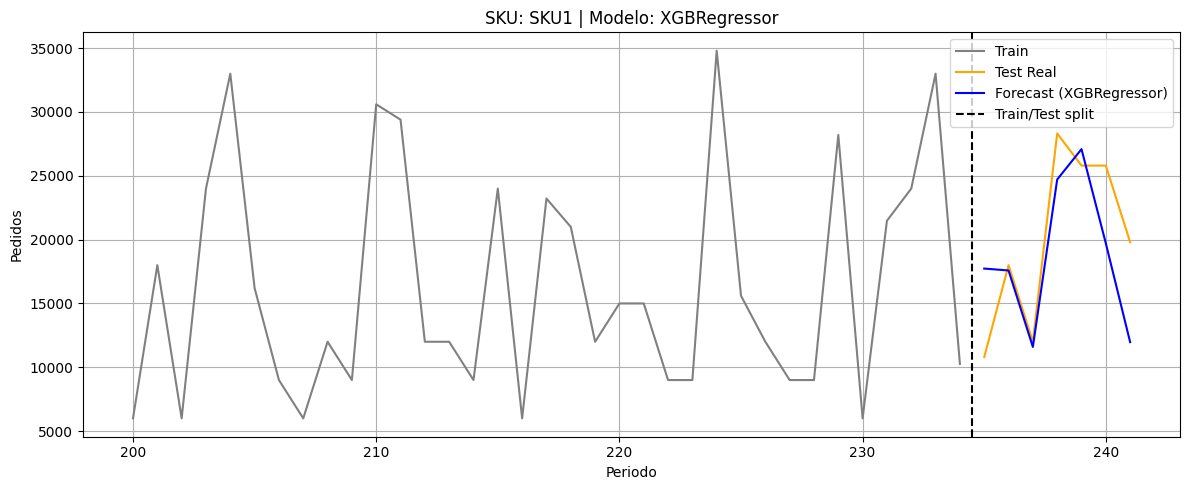

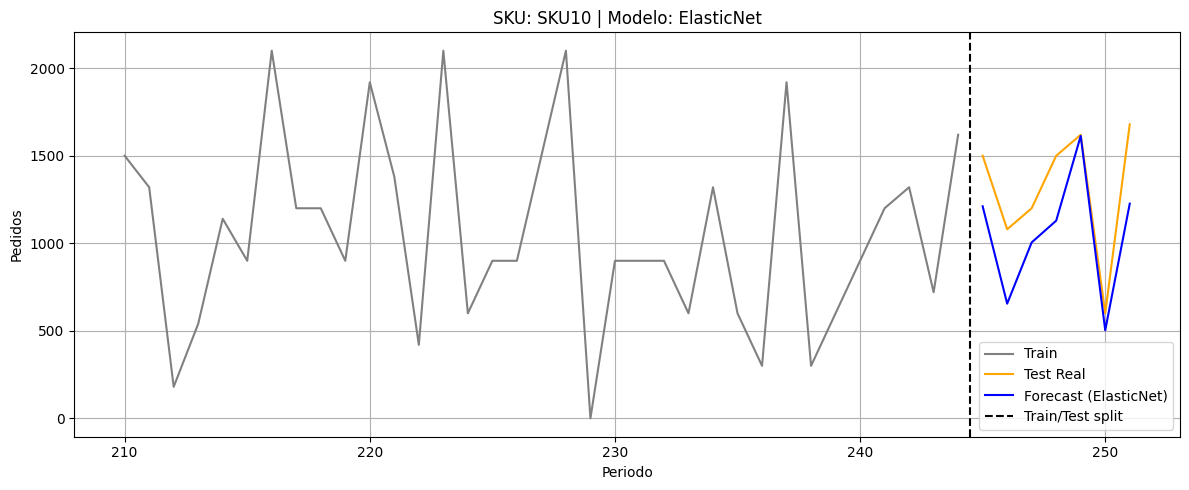

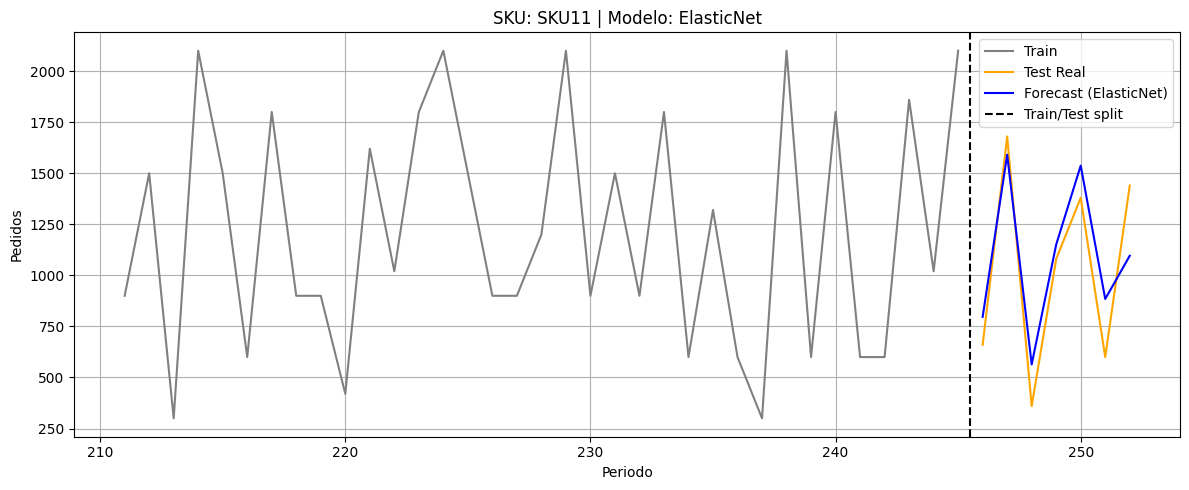

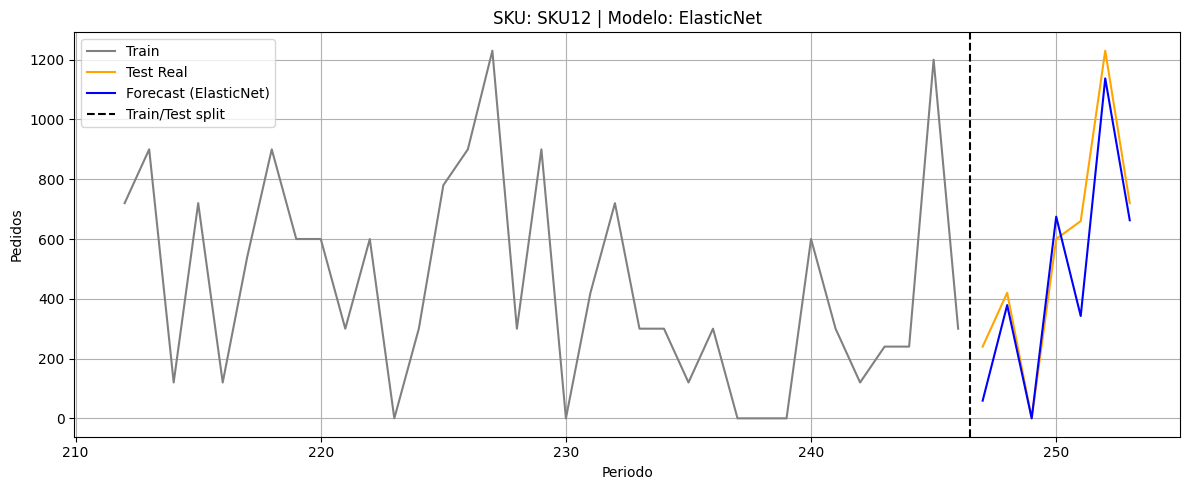

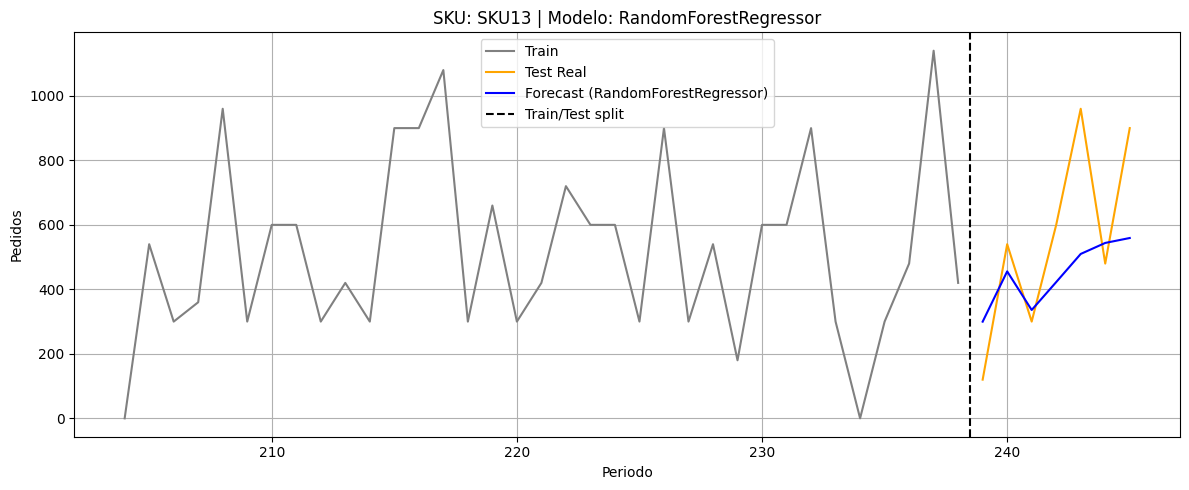

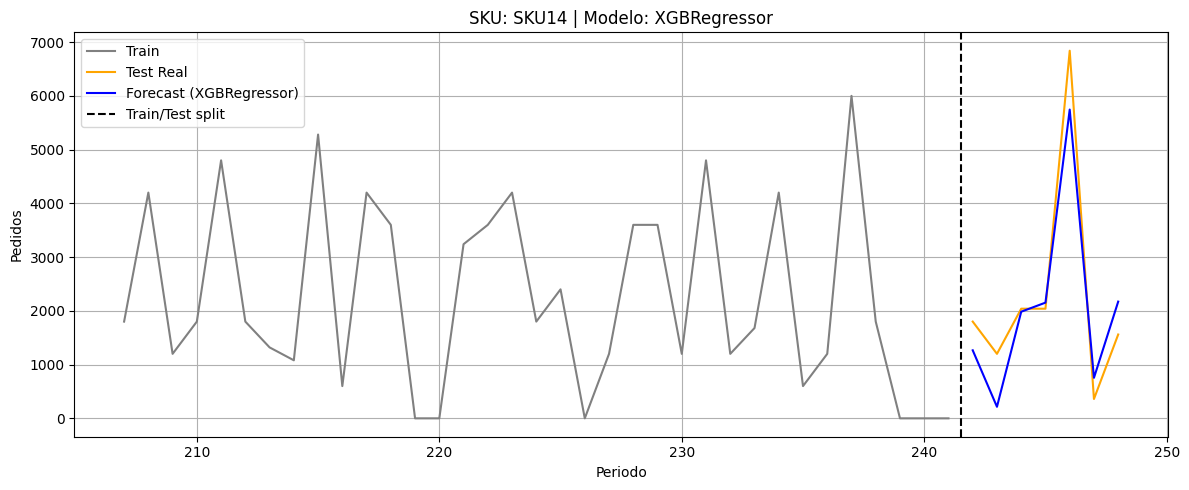

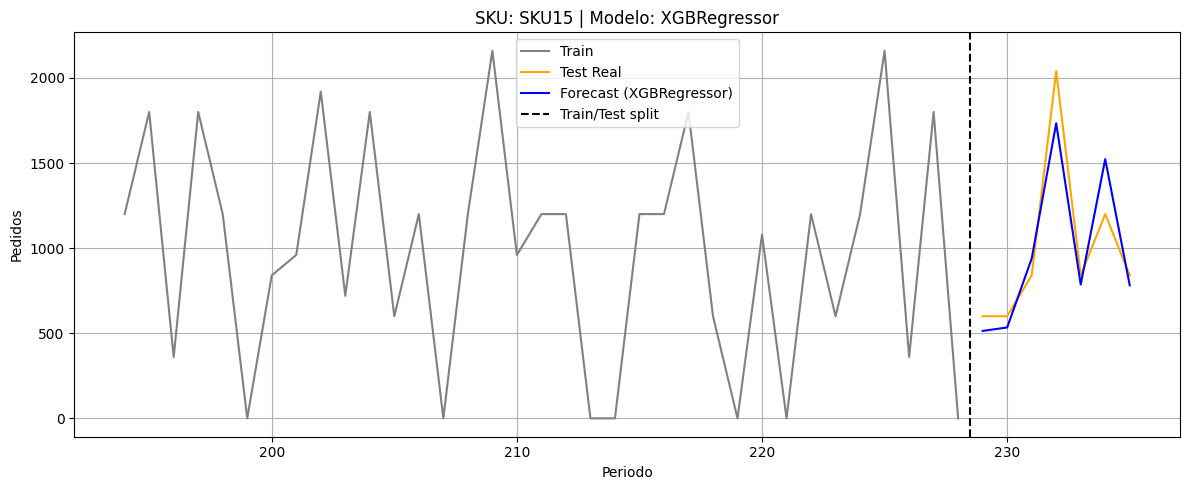

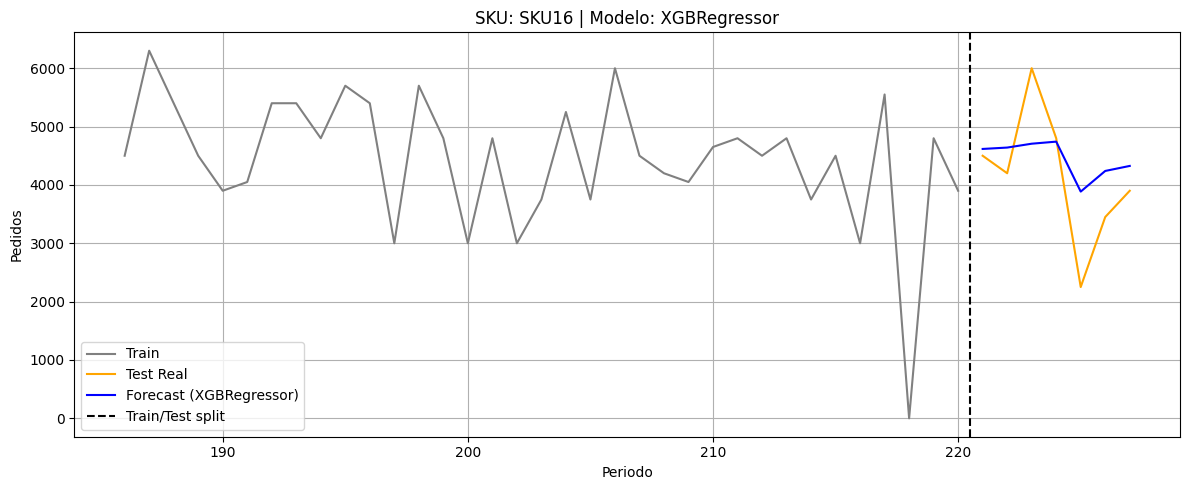

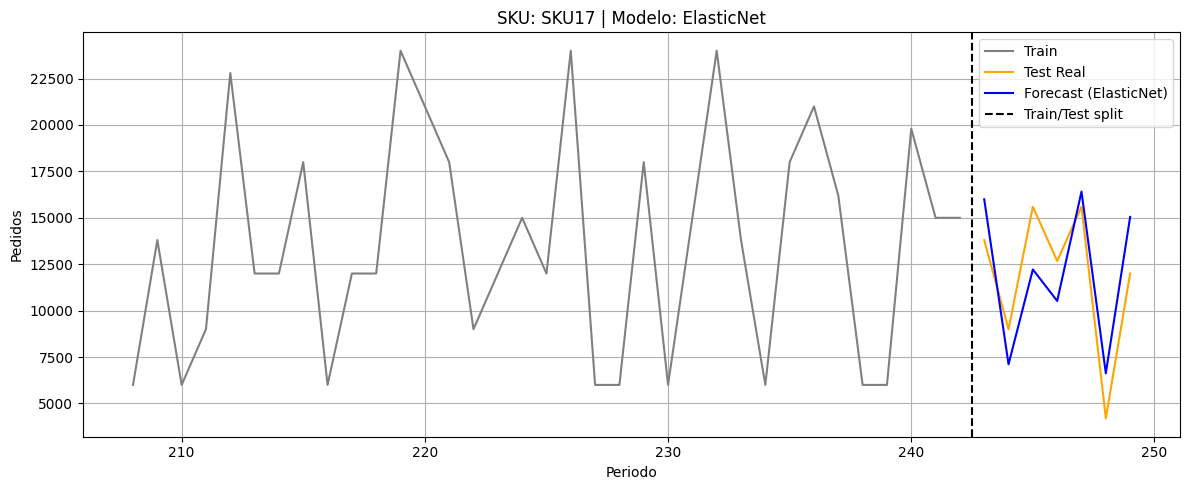

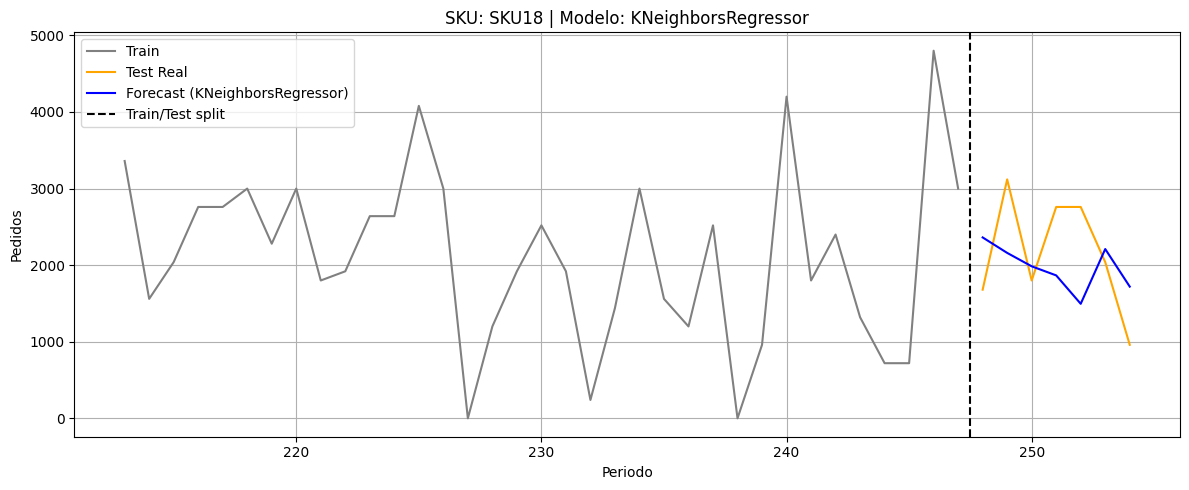

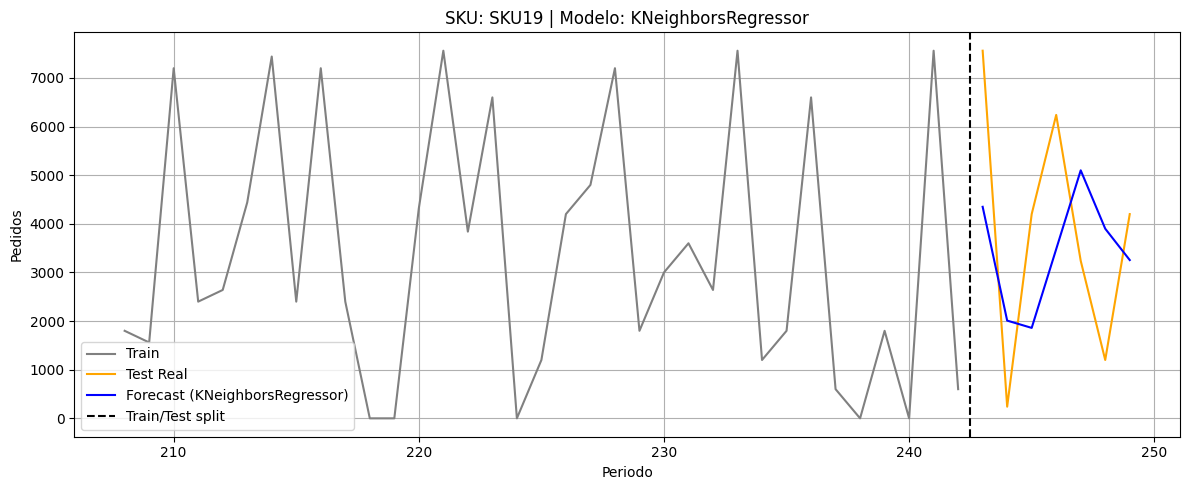

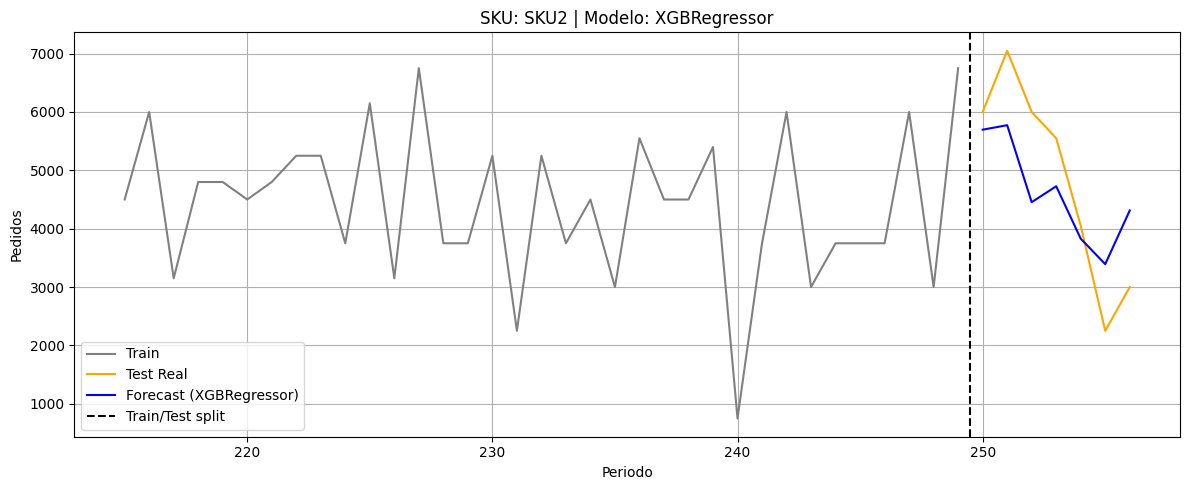

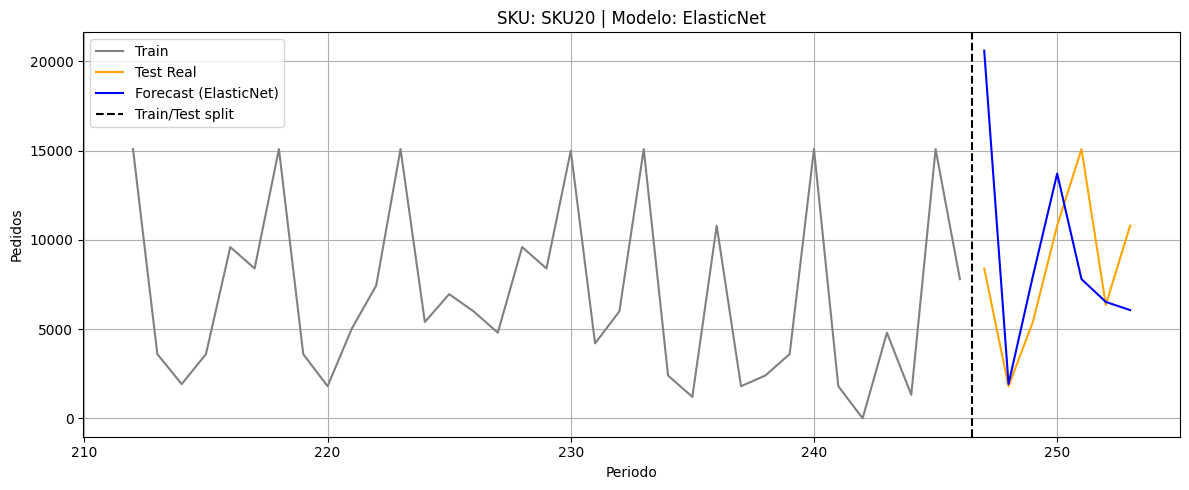

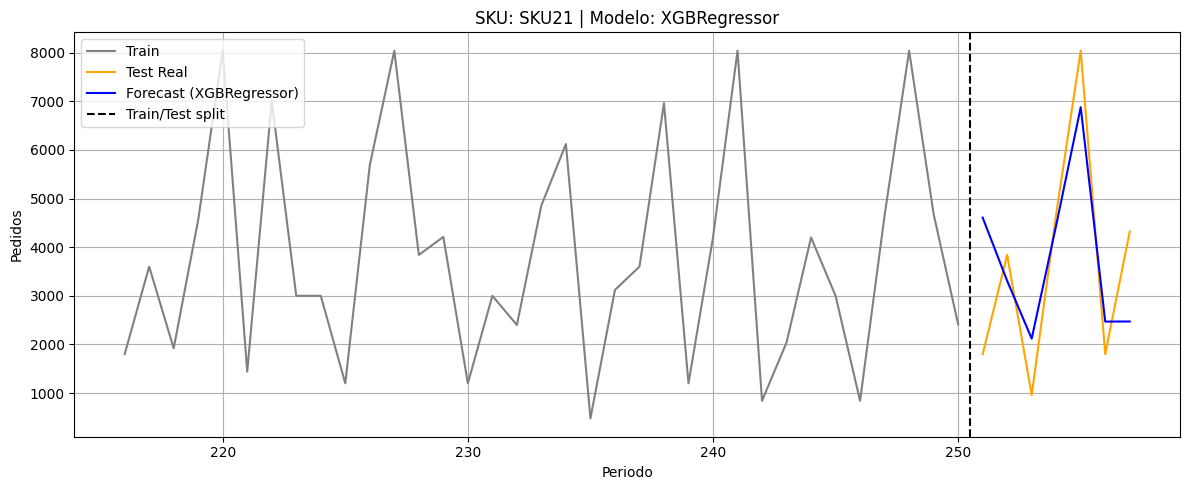

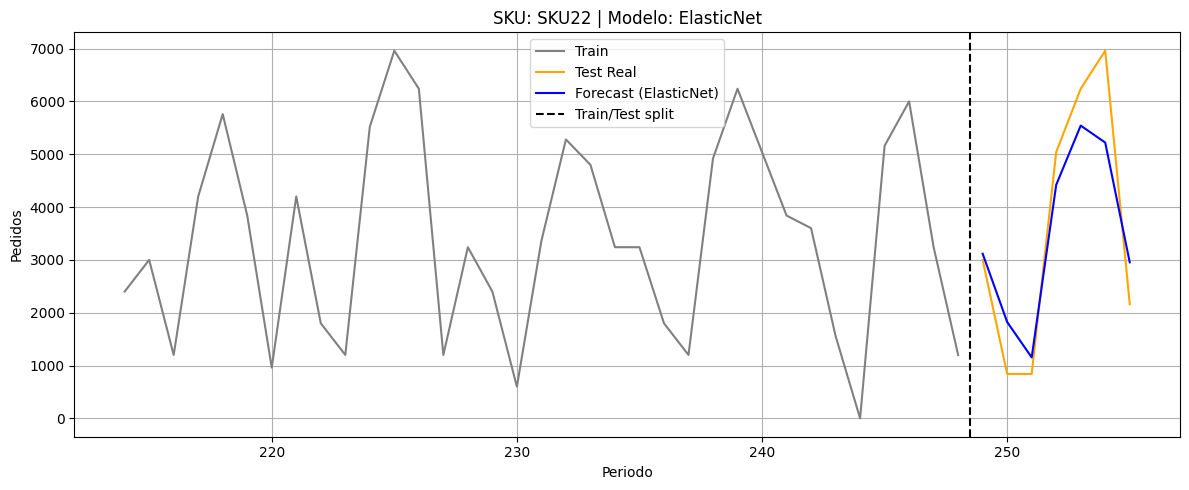

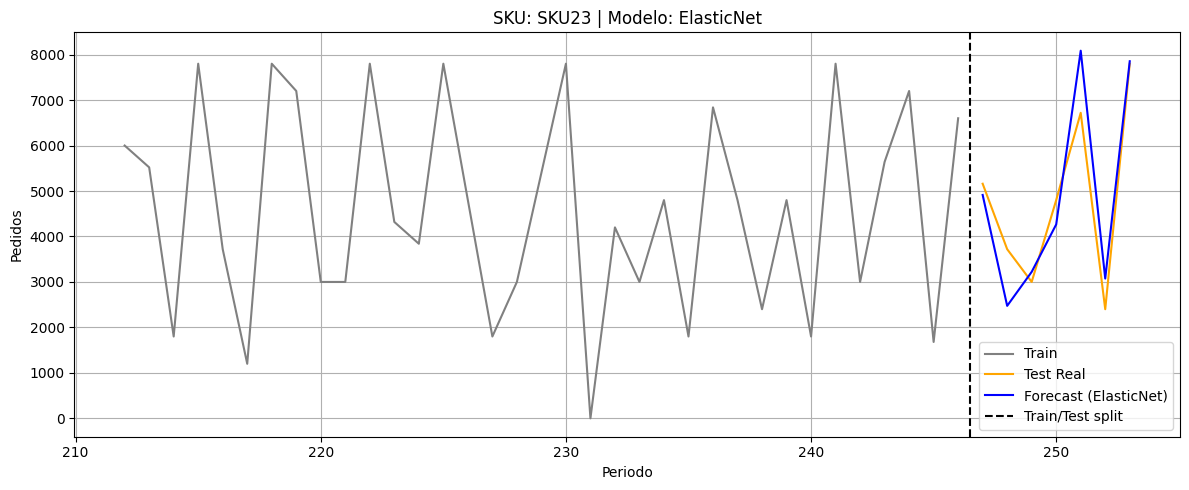

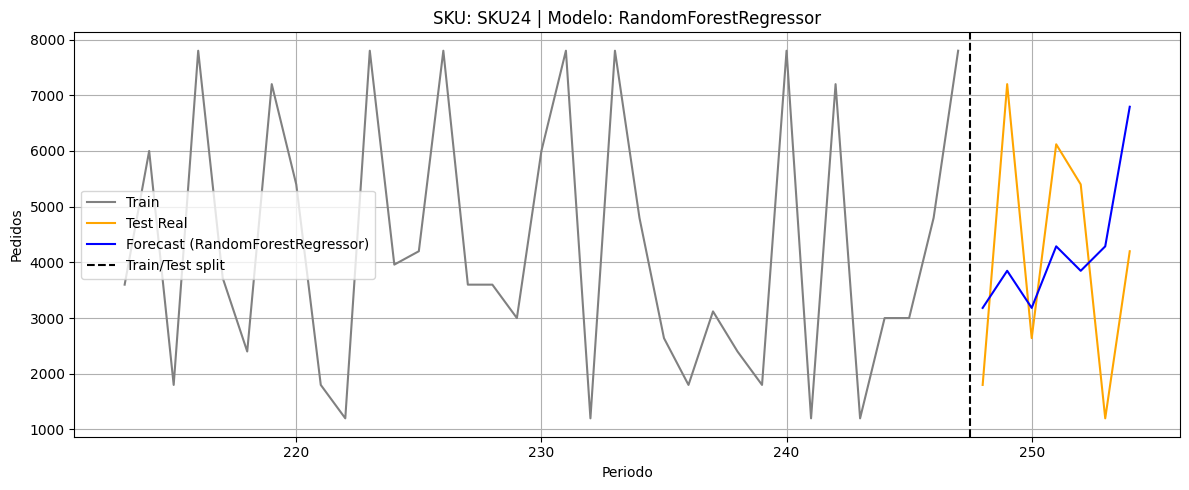

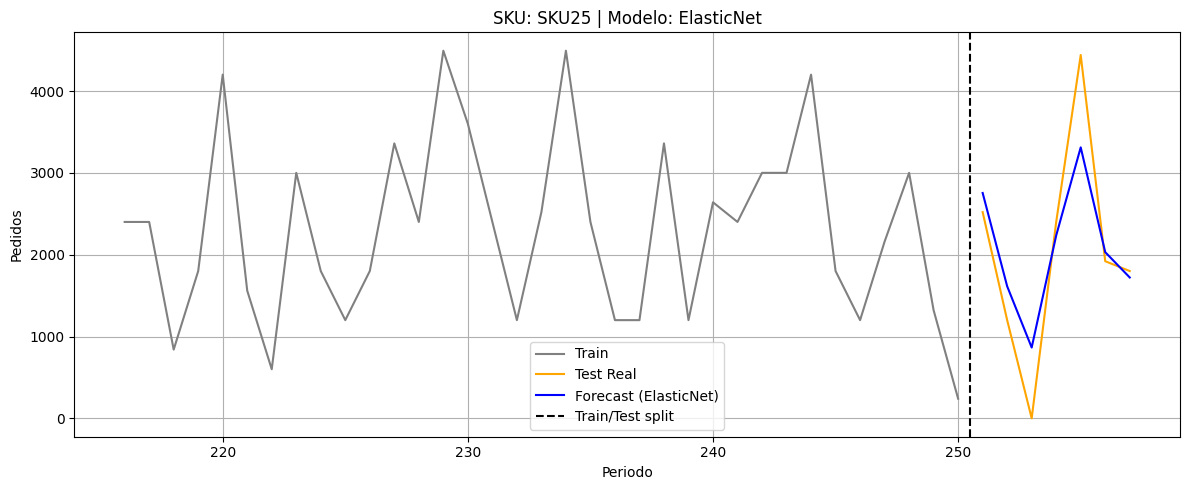

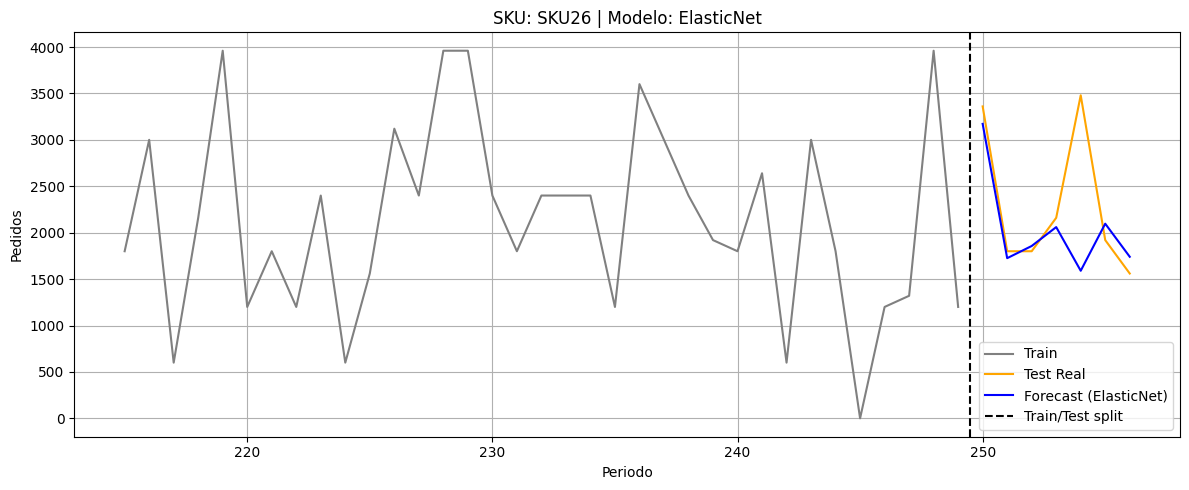

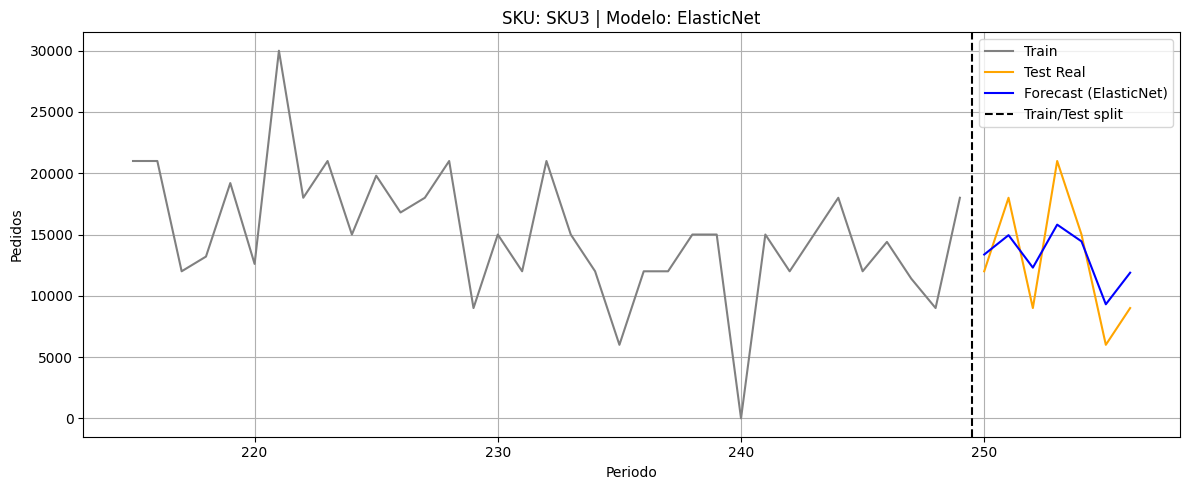

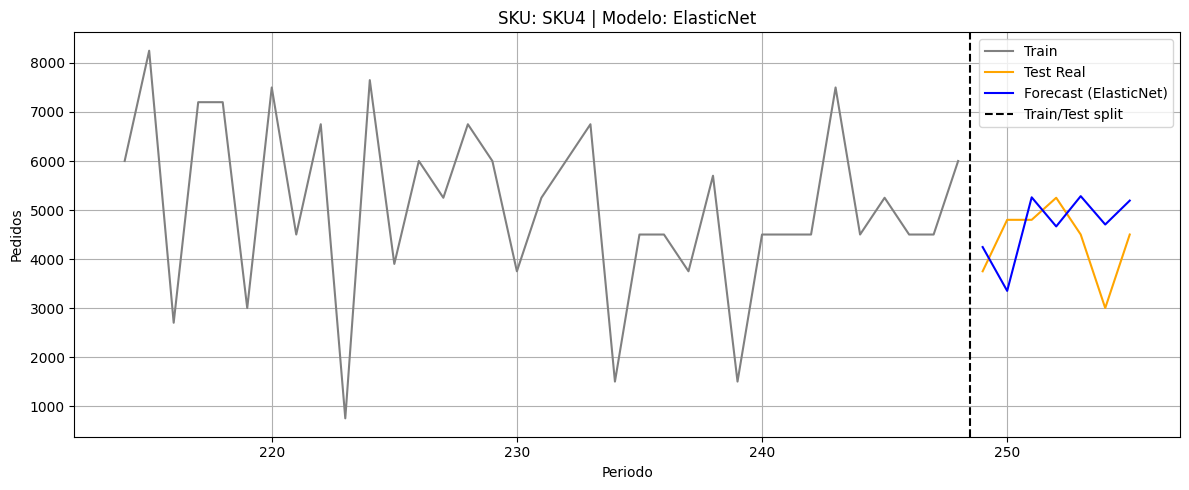

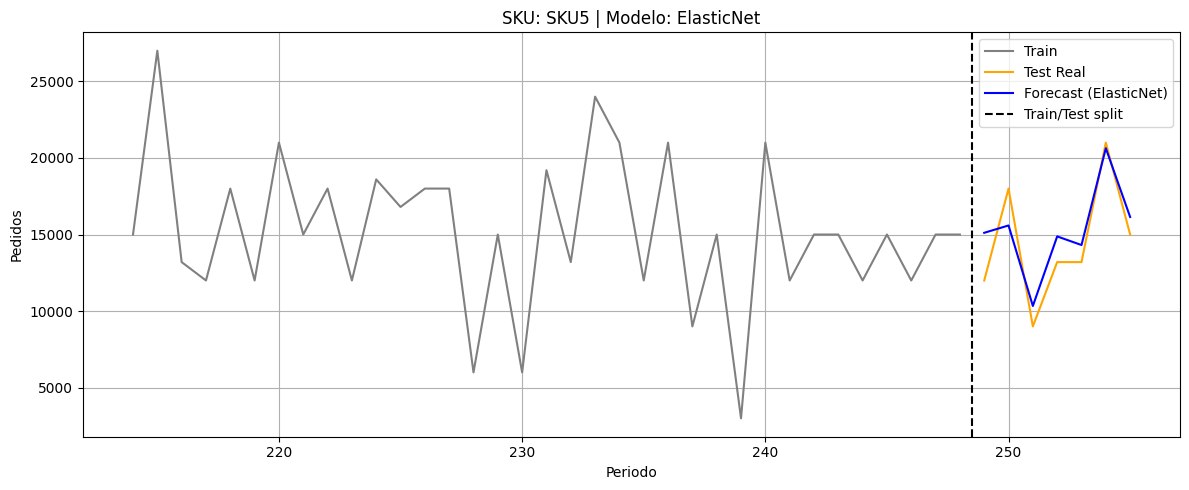

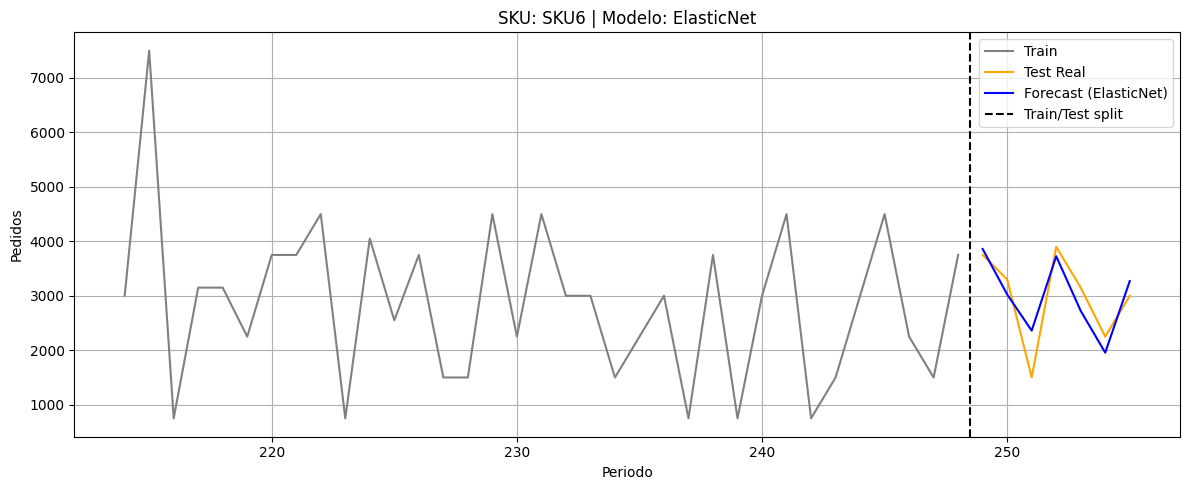

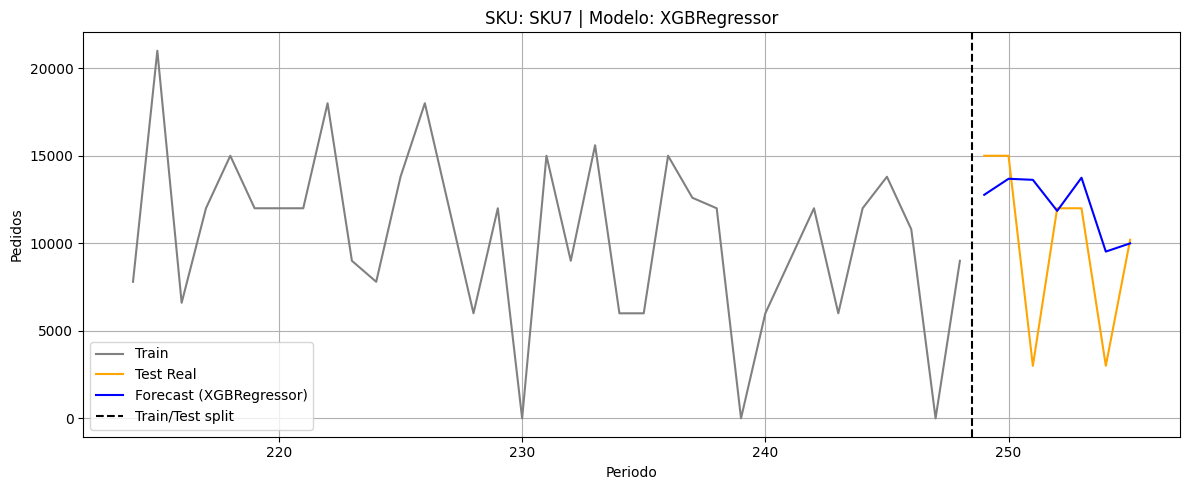

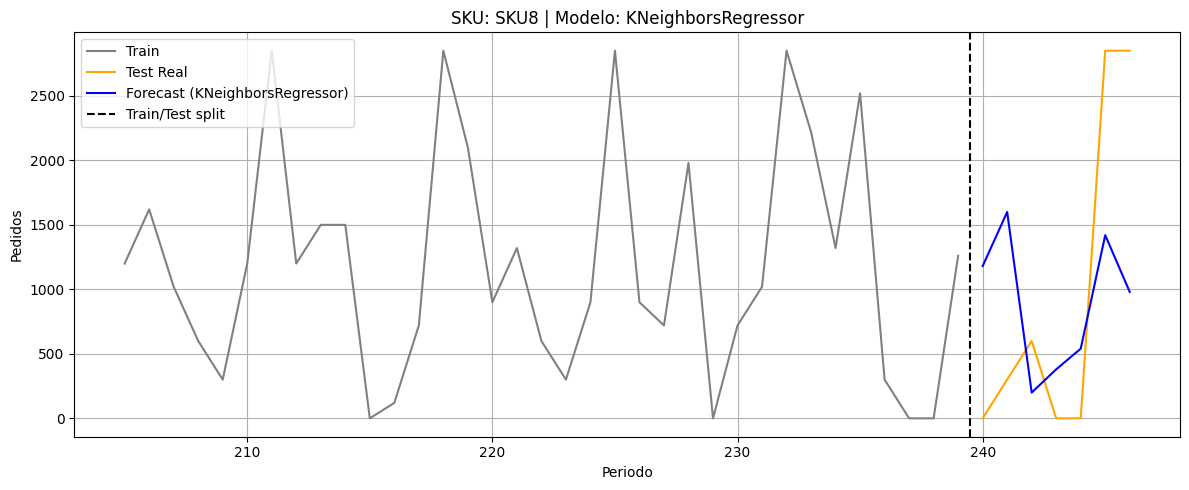

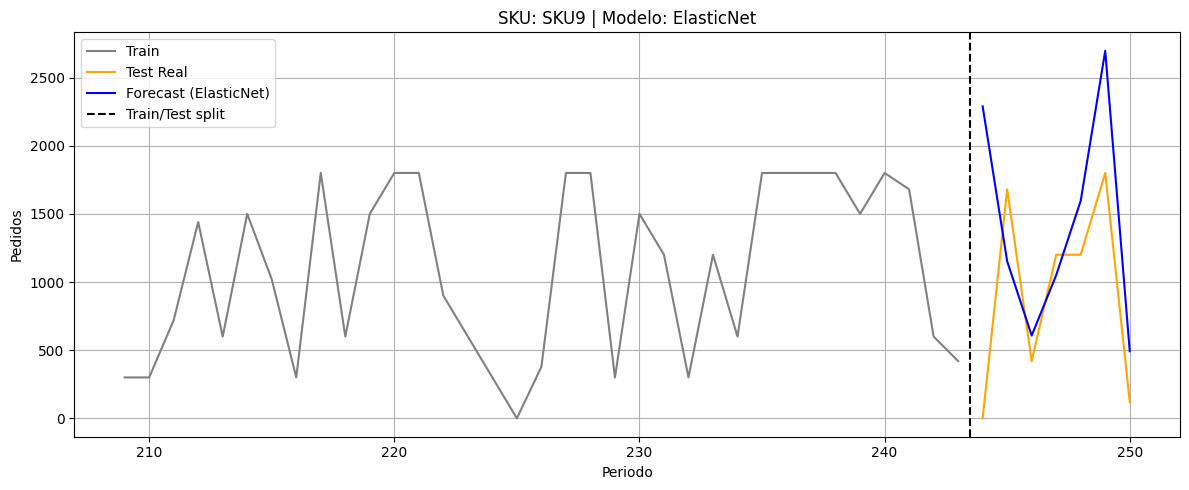

In [43]:
plot_utils.plot_forecast_per_sku(
    df_full=df,
    df_test_results=df_test_results,
    target_col="pedidos",
    sku_col="sku",
    test_size=test_size,
    n_train_days=test_size
    * 5,  # Usamos 5 veces el tamaño del test set para el entrenamiento
)
